In [194]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter
from tqdm import tqdm

In [195]:
PROJECT_ROOT = Path("/Users/user/Deep-Learning-PCB-Defect-Detection")

DATA_ROOT = PROJECT_ROOT / "data"

DEEPPCB_ROOT = DATA_ROOT / "DeepPCB"
PKU_ROOT = DATA_ROOT / "PKU-Market-PCB(Data enhanced version)"

DATASETS = {
    "DeepPCB": DEEPPCB_ROOT,
    "PKU": PKU_ROOT
}

for name, path in DATASETS.items():
    print(f"{name}:")
    print(path)
    print("Exists:", path.exists())
    print()

DeepPCB:
/Users/user/Deep-Learning-PCB-Defect-Detection/data/DeepPCB
Exists: True

PKU:
/Users/user/Deep-Learning-PCB-Defect-Detection/data/PKU-Market-PCB(Data enhanced version)
Exists: True



In [196]:
def show_dataset_structure(dataset_name, dataset_root):
    print("=" * 70)
    print(dataset_name)
    print("=" * 70)

    for split in ["train", "valid", "test"]:
        split_dir = dataset_root / split
        image_dir = split_dir / "images"
        label_dir = split_dir / "labels"

        print(f"\n[{split}]")
        print(f"  images : {image_dir.exists()} -> {image_dir}")
        print(f"  labels : {label_dir.exists()} -> {label_dir}")

        if image_dir.exists():
            image_count = len([
                p for p in image_dir.iterdir()
                if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
            ])
            print(f"  image count: {image_count}")

        if label_dir.exists():
            label_count = len(list(label_dir.glob("*.txt")))
            print(f"  label count: {label_count}")

    class_file = dataset_root / "Class.txt"
    print(f"\nClass.txt: {class_file.exists()} -> {class_file}")


for name, root in DATASETS.items():
    show_dataset_structure(name, root)

DeepPCB

[train]
  images : True -> /Users/user/Deep-Learning-PCB-Defect-Detection/data/DeepPCB/train/images
  labels : True -> /Users/user/Deep-Learning-PCB-Defect-Detection/data/DeepPCB/train/labels
  image count: 107
  label count: 325

[valid]
  images : True -> /Users/user/Deep-Learning-PCB-Defect-Detection/data/DeepPCB/valid/images
  labels : True -> /Users/user/Deep-Learning-PCB-Defect-Detection/data/DeepPCB/valid/labels
  image count: 150
  label count: 150

[test]
  images : True -> /Users/user/Deep-Learning-PCB-Defect-Detection/data/DeepPCB/test/images
  labels : True -> /Users/user/Deep-Learning-PCB-Defect-Detection/data/DeepPCB/test/labels
  image count: 150
  label count: 150

Class.txt: True -> /Users/user/Deep-Learning-PCB-Defect-Detection/data/DeepPCB/Class.txt
PKU

[train]
  images : True -> /Users/user/Deep-Learning-PCB-Defect-Detection/data/PKU-Market-PCB(Data enhanced version)/train/images
  labels : True -> /Users/user/Deep-Learning-PCB-Defect-Detection/data/PKU-Ma

In [197]:
# read class.txt
def read_class_file(class_path):
    classes = []

    with open(class_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            classes.append(line)

    return classes

for dataset_name, dataset_root in DATASETS.items():

    class_path = dataset_root / "Class.txt"

    classes = read_class_file(class_path)

    print("=" * 50)
    print(dataset_name)
    print("=" * 50)

    for class_id, class_name in enumerate(classes):
        print(f"{class_id}: {class_name}")

DeepPCB
0: 'open','short','mousebite','spur','copper','pin-hole'
PKU
0: 'Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper'


In [198]:
# read image information
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}


def collect_image_information(dataset_name, dataset_root):

    records = []

    for split in ["train", "valid", "test"]:

        image_dir = dataset_root / split / "images"

        if not image_dir.exists():
            continue

        image_files = [
            p for p in image_dir.iterdir()
            if p.suffix.lower() in IMAGE_EXTENSIONS
        ]

        for image_path in tqdm(
            image_files,
            desc=f"{dataset_name} - {split}"
        ):

            try:
                with Image.open(image_path) as img:

                    width, height = img.size
                    mode = img.mode

                label_path = (
                    dataset_root
                    / split
                    / "labels"
                    / f"{image_path.stem}.txt"
                )

                records.append({
                    "dataset": dataset_name,
                    "split": split,
                    "image": image_path.name,
                    "image_path": str(image_path),
                    "label_path": str(label_path),
                    "width": width,
                    "height": height,
                    "mode": mode,
                    "format": image_path.suffix.lower(),
                    "label_exists": label_path.exists()
                })

            except Exception as e:

                print(
                    f"Error reading {image_path}: {e}"
                )

    return pd.DataFrame(records)

image_df_list = []

for dataset_name, dataset_root in DATASETS.items():

    df = collect_image_information(
        dataset_name,
        dataset_root
    )

    image_df_list.append(df)

image_df = pd.concat(
    image_df_list,
    ignore_index=True
)

image_df.head()


PKU - test: 100%|██████████| 53/53 [00:00<00:00, 2262.07it/s]


,dataset,split,image,image_path,label_path,width,height,mode,format,label_exists
0,DeepPCB,train,01_PCB__564.jpg,/Users/user/Deep-Learning-PCB-Defect-Detection...,/Users/user/Deep-Learning-PCB-Defect-Detection...,640,640,L,.jpg,True
1,DeepPCB,train,01_PCB__559.jpg,/Users/user/Deep-Learning-PCB-Defect-Detection...,/Users/user/Deep-Learning-PCB-Defect-Detection...,640,640,L,.jpg,True
2,DeepPCB,train,01_PCB__565.jpg,/Users/user/Deep-Learning-PCB-Defect-Detection...,/Users/user/Deep-Learning-PCB-Defect-Detection...,640,640,L,.jpg,True
3,DeepPCB,train,01_PCB__598.jpg,/Users/user/Deep-Learning-PCB-Defect-Detection...,/Users/user/Deep-Learning-PCB-Defect-Detection...,640,640,L,.jpg,True
4,DeepPCB,train,01_PCB__567.jpg,/Users/user/Deep-Learning-PCB-Defect-Detection...,/Users/user/Deep-Learning-PCB-Defect-Detection...,640,640,L,.jpg,False


In [199]:
print(
    image_df.groupby(
        ["dataset", "split"]
    )["label_exists"].agg(
        ["count", "sum"]
    )
)

               count  sum
dataset split            
DeepPCB test     150  150
        train    107   56
        valid    150  150
PKU     test      53   53
        train    539  245
        valid    367  170


In [200]:
missing_labels = image_df[
    ~image_df["label_exists"]
]

print("Images without labels:", len(missing_labels))

missing_labels.head()

Images without labels: 542


,dataset,split,image,image_path,label_path,width,height,mode,format,label_exists
4,DeepPCB,train,01_PCB__567.jpg,/Users/user/Deep-Learning-PCB-Defect-Detection...,/Users/user/Deep-Learning-PCB-Defect-Detection...,640,640,L,.jpg,False
5,DeepPCB,train,01_PCB__573.jpg,/Users/user/Deep-Learning-PCB-Defect-Detection...,/Users/user/Deep-Learning-PCB-Defect-Detection...,640,640,L,.jpg,False
6,DeepPCB,train,01_PCB__639.jpg,/Users/user/Deep-Learning-PCB-Defect-Detection...,/Users/user/Deep-Learning-PCB-Defect-Detection...,640,640,L,.jpg,False
9,DeepPCB,train,01_PCB__562.jpg,/Users/user/Deep-Learning-PCB-Defect-Detection...,/Users/user/Deep-Learning-PCB-Defect-Detection...,640,640,L,.jpg,False
11,DeepPCB,train,01_PCB__628.jpg,/Users/user/Deep-Learning-PCB-Defect-Detection...,/Users/user/Deep-Learning-PCB-Defect-Detection...,640,640,L,.jpg,False


In [201]:
# Parser for DeepPCB
def parse_deeppcb_label(label_path):

    annotations = []

    with open(label_path, "r", encoding="utf-8") as f:

        for line_number, line in enumerate(f, start=1):

            parts = line.strip().split()

            if len(parts) != 5:
                continue

            x1, y1, x2, y2, class_id = parts

            annotations.append({
                "x1": float(x1),
                "y1": float(y1),
                "x2": float(x2),
                "y2": float(y2),
                "class_id": int(class_id)
            })

    return annotations

In [202]:
# Parser for PKU
def parse_pku_label(
    label_path,
    image_width,
    image_height
):

    annotations = []

    with open(label_path, "r", encoding="utf-8") as f:

        for line_number, line in enumerate(f, start=1):

            parts = line.strip().split()

            if len(parts) != 5:
                continue

            class_id = int(parts[0])

            xc = float(parts[1])
            yc = float(parts[2])
            width = float(parts[3])
            height = float(parts[4])

            x1 = (xc - width / 2) * image_width
            y1 = (yc - height / 2) * image_height

            x2 = (xc + width / 2) * image_width
            y2 = (yc + height / 2) * image_height

            annotations.append({
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "class_id": class_id
            })

    return annotations

In [203]:
# annotation
def build_annotation_dataframe(
    dataset_name,
    dataset_root
):

    records = []

    for split in ["train", "valid", "test"]:

        image_dir = dataset_root / split / "images"
        label_dir = dataset_root / split / "labels"

        image_files = [
            p for p in image_dir.iterdir()
            if p.suffix.lower() in IMAGE_EXTENSIONS
        ]

        for image_path in tqdm(
            image_files,
            desc=f"Annotations - {dataset_name} - {split}"
        ):

            label_path = (
                label_dir /
                f"{image_path.stem}.txt"
            )

            if not label_path.exists():
                continue

            with Image.open(image_path) as img:
                image_width, image_height = img.size

            if dataset_name == "DeepPCB":

                annotations = parse_deeppcb_label(
                    label_path
                )

            elif dataset_name == "PKU":

                annotations = parse_pku_label(
                    label_path,
                    image_width,
                    image_height
                )

            else:
                raise ValueError(
                    f"Unknown dataset: {dataset_name}"
                )

            for defect_id, ann in enumerate(
                annotations
            ):

                records.append({
                    "dataset": dataset_name,
                    "split": split,
                    "image": image_path.name,
                    "image_path": str(image_path),
                    "label_path": str(label_path),
                    "defect_id": defect_id,
                    "class_id": ann["class_id"],
                    "x1": ann["x1"],
                    "y1": ann["y1"],
                    "x2": ann["x2"],
                    "y2": ann["y2"],
                    "image_width": image_width,
                    "image_height": image_height
                })

    return pd.DataFrame(records)

In [204]:
annotation_df_list = []

for dataset_name, dataset_root in DATASETS.items():

    df = build_annotation_dataframe(
        dataset_name,
        dataset_root
    )

    annotation_df_list.append(df)

annotation_df = pd.concat(
    annotation_df_list,
    ignore_index=True
)

annotation_df.head()

Annotations - PKU - test: 100%|██████████| 53/53 [00:00<00:00, 2171.33it/s]


,dataset,split,image,image_path,label_path,defect_id,class_id,x1,y1,x2,y2,image_width,image_height
0,DeepPCB,train,01_PCB__564.jpg,/Users/user/Deep-Learning-PCB-Defect-Detection...,/Users/user/Deep-Learning-PCB-Defect-Detection...,0,1,232.0,301.0,280.0,342.0,640,640
1,DeepPCB,train,01_PCB__564.jpg,/Users/user/Deep-Learning-PCB-Defect-Detection...,/Users/user/Deep-Learning-PCB-Defect-Detection...,1,1,317.0,339.0,363.0,385.0,640,640
2,DeepPCB,train,01_PCB__564.jpg,/Users/user/Deep-Learning-PCB-Defect-Detection...,/Users/user/Deep-Learning-PCB-Defect-Detection...,2,3,378.0,344.0,420.0,372.0,640,640
3,DeepPCB,train,01_PCB__564.jpg,/Users/user/Deep-Learning-PCB-Defect-Detection...,/Users/user/Deep-Learning-PCB-Defect-Detection...,3,6,506.0,41.0,544.0,79.0,640,640
4,DeepPCB,train,01_PCB__564.jpg,/Users/user/Deep-Learning-PCB-Defect-Detection...,/Users/user/Deep-Learning-PCB-Defect-Detection...,4,5,128.0,242.0,171.0,284.0,640,640


In [205]:
print(
    annotation_df.groupby(
        ["dataset", "split"]
    ).size()
)

dataset  split
DeepPCB  test      984
         train     385
         valid    1005
PKU      test      159
         train    1235
         valid     601
dtype: int64


In [206]:
# Class definitions
DEEPPCB_CLASSES = {
    1: "open",
    2: "short",
    3: "mousebite",
    4: "spur",
    5: "copper",
    6: "pin-hole"
}

PKU_CLASSES = {
    0: "Missing_hole",
    1: "Mouse_bite",
    2: "Open_circuit",
    3: "Short",
    4: "Spur",
    5: "Spurious_copper"
}

In [207]:
print(PKU_CLASSES)

{0: 'Missing_hole', 1: 'Mouse_bite', 2: 'Open_circuit', 3: 'Short', 4: 'Spur', 5: 'Spurious_copper'}


In [208]:
class_distribution = (
    annotation_df
    .groupby(
        ["dataset", "split", "class_id"]
    )
    .size()
    .reset_index(name="count")
)

class_distribution

,dataset,split,class_id,count
0,DeepPCB,test,1,191
1,DeepPCB,test,2,170
2,DeepPCB,test,3,194
3,DeepPCB,test,4,153
4,DeepPCB,test,5,140
5,DeepPCB,test,6,136
6,DeepPCB,train,1,60
7,DeepPCB,train,2,44
8,DeepPCB,train,3,85
9,DeepPCB,train,4,64


In [209]:
# FUNCTION TO PLOT CLASS DISTRIBUTION
# ============================================================

def plot_class_distribution(
    class_distribution,
    dataset_name,
    class_mapping
):

    # Filter dataset
    df = class_distribution[
        class_distribution["dataset"] == dataset_name
    ].copy()

    # Get classes and splits
    class_ids = sorted(
        df["class_id"].unique()
    )

    splits = [
        split
        for split in ["train", "valid", "test"]
        if split in df["split"].unique()
    ]

    # Class names
    class_names = [
        class_mapping[class_id]
        for class_id in class_ids
    ]

    # Position of groups
    x = np.arange(len(class_ids))

    # Width of each bar
    width = 0.25

    fig, ax = plt.subplots(
        figsize=(12, 6)
    )

    # Plot each split
    for i, split in enumerate(splits):

        split_data = (
            df[df["split"] == split]
            .set_index("class_id")
            .reindex(class_ids)
        )

        counts = (
            split_data["count"]
            .fillna(0)
            .values
        )

        bars = ax.bar(
            x + (i - (len(splits) - 1) / 2) * width,
            counts,
            width,
            label=split
        )

        # Add values on top of bars
        ax.bar_label(
            bars,
            padding=3,
            fontsize=8
        )

    # X-axis
    ax.set_xticks(x)
    ax.set_xticklabels(
        class_names,
        rotation=20,
        ha="right"
    )

    # Labels
    ax.set_xlabel("Defect Class")
    ax.set_ylabel("Number of Defect Instances")

    ax.set_title(
        f"{dataset_name} - Defect Class Distribution"
    )

    ax.legend(
        title="Dataset Split"
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

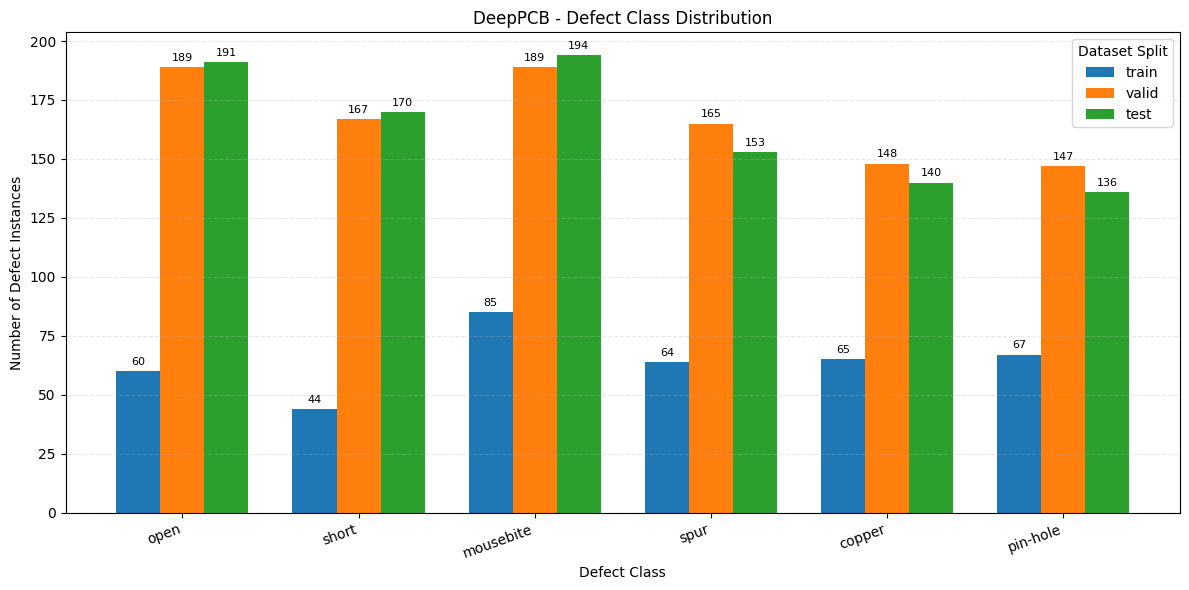

In [210]:
plot_class_distribution(
    class_distribution,
    "DeepPCB",
    DEEPPCB_CLASSES
)

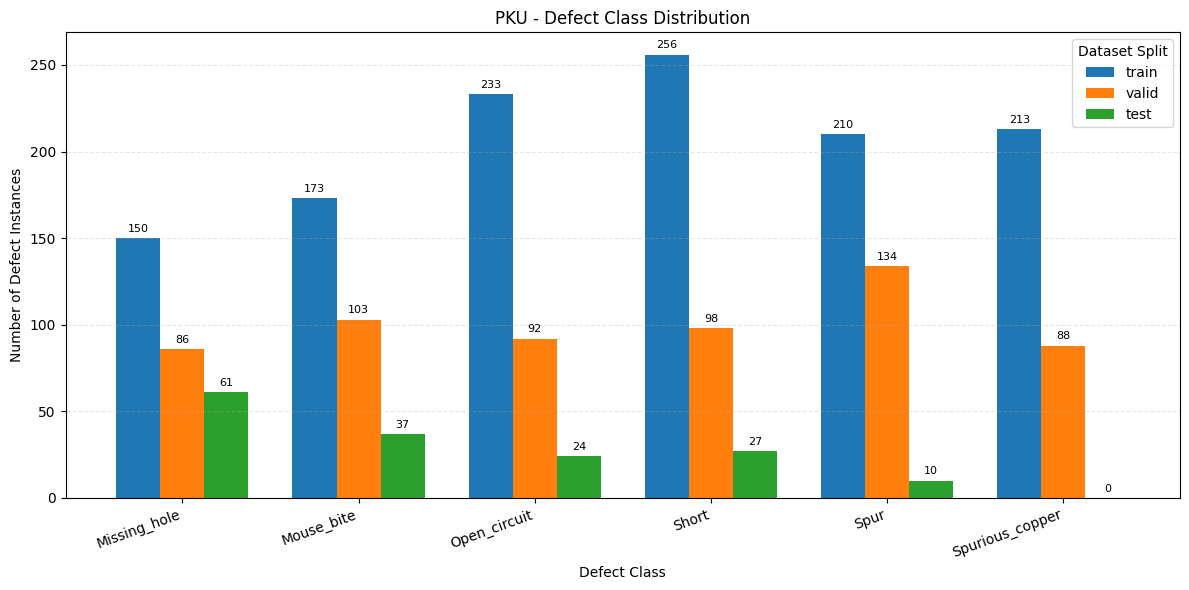

In [211]:
plot_class_distribution(
    class_distribution,
    "PKU",
    PKU_CLASSES
)

In [212]:
overall_distribution = (
    annotation_df
    .groupby(
        ["dataset", "class_id"]
    )
    .size()
    .reset_index(
        name="count"
    )
)

overall_distribution["class_name"] = (
    overall_distribution.apply(
        lambda row: (
            DEEPPCB_CLASSES.get(row["class_id"], "Unknown")
            if row["dataset"] == "DeepPCB"
            else PKU_CLASSES.get(row["class_id"], "Unknown")
        ),
        axis=1
    )
)

overall_distribution

,dataset,class_id,count,class_name
0,DeepPCB,1,440,open
1,DeepPCB,2,381,short
2,DeepPCB,3,468,mousebite
3,DeepPCB,4,382,spur
4,DeepPCB,5,353,copper
5,DeepPCB,6,350,pin-hole
6,PKU,0,297,Missing_hole
7,PKU,1,313,Mouse_bite
8,PKU,2,349,Open_circuit
9,PKU,3,381,Short


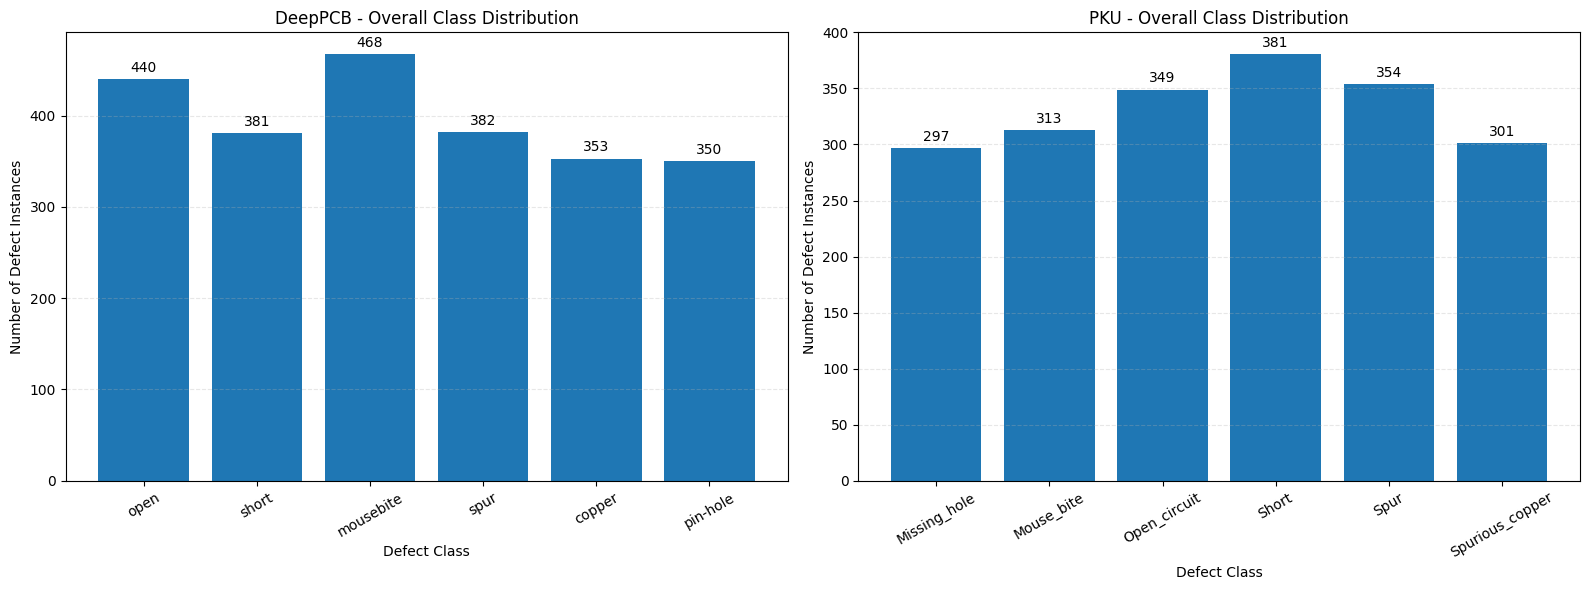

In [213]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6)
)

for ax, dataset_name, class_mapping in zip(
    axes,
    ["DeepPCB", "PKU"],
    [DEEPPCB_CLASSES, PKU_CLASSES]
):

    df = overall_distribution[
        overall_distribution["dataset"] == dataset_name
    ]

    bars = ax.bar(
        df["class_name"],
        df["count"]
    )

    ax.bar_label(
        bars,
        padding=3
    )

    ax.set_title(
        f"{dataset_name} - Overall Class Distribution"
    )

    ax.set_xlabel("Defect Class")
    ax.set_ylabel("Number of Defect Instances")

    ax.tick_params(
        axis="x",
        rotation=30
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

plt.tight_layout()
plt.show()

In [214]:
# DEFECTS PER IMAGE
# Convert class ID to class name
def get_class_name(row):

    if row["dataset"] == "DeepPCB":
        return DEEPPCB_CLASSES.get(
            row["class_id"],
            "Unknown"
        )

    elif row["dataset"] == "PKU":
        return PKU_CLASSES.get(
            row["class_id"],
            "Unknown"
        )

    return "Unknown"


# Add class name
annotation_df["class_name"] = annotation_df.apply(
    get_class_name,
    axis=1
)


# Count defects and list classes for each image


defects_per_image = (
    annotation_df
    .groupby(
        ["dataset", "split", "image"]
    )
    .agg(
        defect_count=(
            "class_id",
            "size"
        ),

        class_ids=(
            "class_id",
            lambda x: ", ".join(
                map(
                    str,
                    sorted(set(x))
                )
            )
        ),

        class_names=(
            "class_name",
            lambda x: ", ".join(
                dict.fromkeys(x)
            )
        )
    )
    .reset_index()
)


# Display only the final result
display(defects_per_image.head(20))

,dataset,split,image,defect_count,class_ids,class_names
0,DeepPCB,test,01_PCB__101.jpg,9,"1, 2, 3, 5, 6","open, short, mousebite, pin-hole, copper"
1,DeepPCB,test,01_PCB__1019.jpg,7,"1, 2, 3, 4, 6","open, short, mousebite, spur, pin-hole"
2,DeepPCB,test,01_PCB__1044.jpg,10,"1, 2, 3, 4, 5, 6","open, short, mousebite, spur, pin-hole, copper"
3,DeepPCB,test,01_PCB__1047.jpg,7,"1, 2, 3, 4, 5, 6","open, short, mousebite, spur, copper, pin-hole"
4,DeepPCB,test,01_PCB__1053.jpg,6,"1, 3, 4, 5, 6","open, mousebite, spur, copper, pin-hole"
5,DeepPCB,test,01_PCB__1057.jpg,6,"1, 2, 3, 5, 6","open, short, mousebite, copper, pin-hole"
6,DeepPCB,test,01_PCB__1078.jpg,7,"1, 2, 3, 4, 5, 6","open, short, mousebite, spur, copper, pin-hole"
7,DeepPCB,test,01_PCB__1082.jpg,7,"1, 2, 3, 5, 6","open, short, mousebite, copper, pin-hole"
8,DeepPCB,test,01_PCB__1085.jpg,7,"1, 2, 3, 4, 5, 6","open, short, mousebite, spur, copper, pin-hole"
9,DeepPCB,test,01_PCB__1100.jpg,9,"1, 2, 3, 4, 5, 6","open, short, mousebite, spur, copper, pin-hole"


In [215]:
print(
    defects_per_image
    .groupby(["dataset", "split"])["defect_count"]
    .describe()
)

               count      mean       std  min  25%  50%  75%   max
dataset split                                                     
DeepPCB test   150.0  6.560000  1.807813  1.0  5.0  7.0  8.0  12.0
        train   56.0  6.875000  1.945274  3.0  5.0  7.0  8.0  12.0
        valid  150.0  6.700000  1.845546  3.0  5.0  7.0  8.0  13.0
PKU     test    53.0  3.000000  0.650444  1.0  3.0  3.0  3.0   6.0
        train  245.0  5.040816  0.198270  5.0  5.0  5.0  5.0   6.0
        valid  170.0  3.535294  1.003804  2.0  3.0  3.0  5.0   6.0


In [216]:
# bounding box
def validate_bbox(row):

    x1 = row["x1"]
    y1 = row["y1"]
    x2 = row["x2"]
    y2 = row["y2"]

    width = row["image_width"]
    height = row["image_height"]

    valid = (
        x1 >= 0
        and y1 >= 0
        and x2 <= width
        and y2 <= height
        and x2 > x1
        and y2 > y1
    )

    return valid

In [217]:
annotation_df["bbox_valid"] = (
    annotation_df.apply(
        validate_bbox,
        axis=1
    )
)
print(
    annotation_df["bbox_valid"].value_counts()
)

bbox_valid
True    4369
Name: count, dtype: int64


In [218]:
invalid_bbox = annotation_df[
    ~annotation_df["bbox_valid"]
]

invalid_bbox.head()

,dataset,split,image,image_path,label_path,defect_id,class_id,x1,y1,x2,y2,image_width,image_height,class_name,bbox_valid


In [219]:
# Visualization bounding boxes
import matplotlib.patches as patches

def visualize_annotation(
    annotation_df,
    dataset_name,
    split,
    image_name
):

    rows = annotation_df[
        (annotation_df["dataset"] == dataset_name)
        & (annotation_df["split"] == split)
        & (annotation_df["image"] == image_name)
    ]

    if rows.empty:
        print("No annotation found.")
        return

    image_path = rows.iloc[0]["image_path"]

    image = Image.open(image_path)

    fig, ax = plt.subplots(
        figsize=(12, 8)
    )

    ax.imshow(image)

    for _, row in rows.iterrows():

        x1 = row["x1"]
        y1 = row["y1"]

        width = row["x2"] - row["x1"]
        height = row["y2"] - row["y1"]

        rect = patches.Rectangle(
            (x1, y1),
            width,
            height,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rect)

        ax.text(
            x1,
            y1,
            f"class {row['class_id']}",
            fontsize=10
        )

    ax.set_title(
        f"{dataset_name} - {split} - {image_name}"
    )

    plt.show()

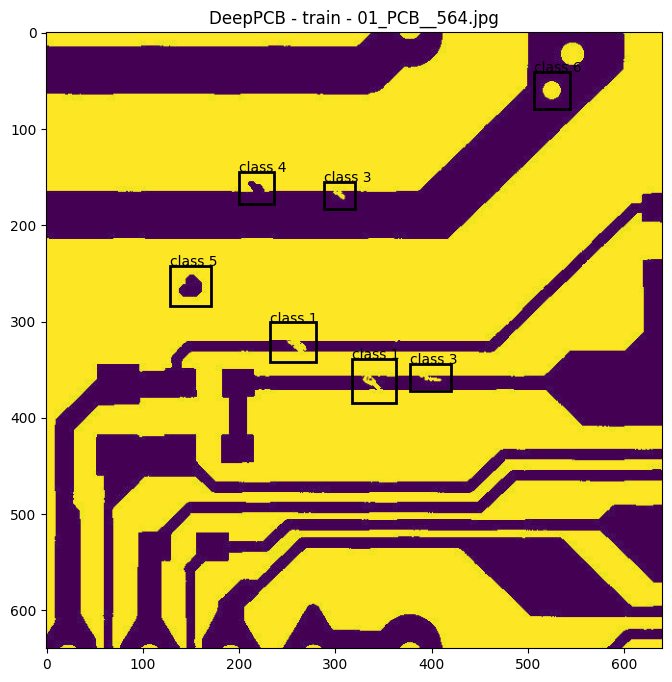

In [220]:
sample_row = annotation_df.iloc[0]

visualize_annotation(
    annotation_df,
    sample_row["dataset"],
    sample_row["split"],
    sample_row["image"]
)

In [221]:
STAGE1_DIR = PROJECT_ROOT / "outputs" / "stage1"

(STAGE1_DIR / "reports").mkdir(
    parents=True,
    exist_ok=True
)

(STAGE1_DIR / "visualizations").mkdir(
    parents=True,
    exist_ok=True
)

In [222]:
image_df.to_csv(
    STAGE1_DIR / "reports" / "image_report.csv",
    index=False
)

annotation_df.to_csv(
    STAGE1_DIR / "reports" / "annotations_report.csv",
    index=False
)

defects_per_image.to_csv(
    STAGE1_DIR / "reports" / "defects_per_image.csv",
    index=False
)

class_distribution.to_csv(
    STAGE1_DIR / "reports" / "class_distribution.csv",
    index=False
)